# Modèles classiques sur Amazon DLBAC (jeu le plus complexe)

Ce notebook entraîne des **classifieurs sklearn** sur le pipeline **one-hot DLBACα** (comme le papier).

**Jeu par défaut : `amazon1`** — plus grande dimension après one-hot (~**14 419** colonnes), donc le plus lourd en mémoire / temps.  
(`amazon2` / `amazon3` : 13 métadonnées brutes mais one-hot plus petit ~9–10k.)

**Modèles** : régression logistique, SVM linéaire, forêt aléatoire, HistGradientBoosting, (optionnel) XGBoost.

**Métriques** : accuracy, AUROC, balanced accuracy, deny F1/recall (seuil tuné sur validation pour le déséquilibre grant/deny).

Prérequis : `DlbacAlpha-main/dataset/real-world/amazon1/` (fichiers `.sample`).

In [1]:
from __future__ import annotations

import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

warnings.filterwarnings("ignore", category=FutureWarning)

_cwd = Path.cwd().resolve()
ROOT = next((p for p in (_cwd, _cwd.parent) if (p / "prepare_dlbac_datasets.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Ouvrez le notebook depuis notebooks/ ou HyConEx_from_scratch/")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from prepare_dlbac_datasets import discover_dlbac_datasets, prepare_dataset
from nouveau_module.binary_metrics import (
    deny_class_metrics,
    predict_with_grant_threshold,
    summarize_binary_metrics,
    tune_grant_threshold,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
print("Racine projet :", ROOT)

Racine projet : D:\ecole\master 2\recherche\INN\projet\HyConEx_from_scratch


## Configuration

In [2]:
# amazon1 = one-hot le plus grand (~14k). amazon2/3 = 13 meta brutes.
DATASET_NAME = "amazon1"
RANDOM_STATE = 42
VAL_SIZE = 0.2
TUNE_METRIC = "deny_f1"  # seuil sur P(grant) optimisé sur val

# Réduire la forêt si trop lent (14k features)
RF_N_ESTIMATORS = 120
RF_MAX_DEPTH = 16
RUN_RANDOM_FOREST = True
RUN_XGBOOST = True  # ignoré si xgboost non installé

## Chargement (one-hot DLBACα)

In [3]:
specs = {s.name: s for s in discover_dlbac_datasets() if s.name.startswith("amazon")}
if DATASET_NAME not in specs:
    raise KeyError(f"{DATASET_NAME} introuvable. Disponibles: {sorted(specs)}")

print("Jeux Amazon :")
for name in sorted(specs):
    mark = " <--" if name == DATASET_NAME else ""
    print(f"  {name}{mark}")

t0 = time.perf_counter()
prep = prepare_dataset(specs[DATASET_NAME], val_size=VAL_SIZE, random_state=RANDOM_STATE)
elapsed = time.perf_counter() - t0

X_train, y_train = prep.x_train, prep.y_train
X_val, y_val = prep.x_val, prep.y_val
X_test, y_test = prep.x_test, prep.y_test
class_names = prep.class_names

print(f"\n{DATASET_NAME} chargé en {elapsed:.1f}s")
print(f"  one-hot : {X_train.shape[1]} colonnes")
print(f"  train/val/test : {X_train.shape[0]} / {X_val.shape[0]} / {X_test.shape[0]}")
for split, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    c = np.bincount(y, minlength=2)
    print(f"  {split}: deny={c[0]} ({100*c[0]/len(y):.1f}%), grant={c[1]} ({100*c[1]/len(y):.1f}%)")

Jeux Amazon :
  amazon1 <--
  amazon2
  amazon3

amazon1 chargé en 37.7s
  one-hot : 14419 colonnes
  train/val/test : 20972 / 5244 / 6553
  train: deny=1207 (5.8%), grant=19765 (94.2%)
  val: deny=302 (5.8%), grant=4942 (94.2%)
  test: deny=388 (5.9%), grant=6165 (94.1%)


## Entraînement des modèles classiques

In [4]:
def evaluate_classifier(name, clf, *, fit_kwargs=None):
    fit_kwargs = fit_kwargs or {}
    t0 = time.perf_counter()
    clf.fit(X_train, y_train, **fit_kwargs)
    fit_s = time.perf_counter() - t0

    if hasattr(clf, "predict_proba"):
        proba_val = clf.predict_proba(X_val)
        proba_test = clf.predict_proba(X_test)
    else:
        # CalibratedClassifierCV ou decision_function
        if hasattr(clf, "decision_function"):
            dv = clf.decision_function(X_val)
            dt = clf.decision_function(X_test)
            proba_val = np.column_stack([-dv, dv])
            proba_val = (proba_val - proba_val.min()) / (proba_val.ptp() + 1e-9)
            proba_val = proba_val / proba_val.sum(axis=1, keepdims=True)
            proba_test = np.column_stack([-dt, dt])
            proba_test = (proba_test - proba_test.min()) / (proba_test.ptp() + 1e-9)
            proba_test = proba_test / proba_test.sum(axis=1, keepdims=True)
        else:
            raise ValueError(f"{name}: pas de proba")

    thresh, tune_info = tune_grant_threshold(proba_val, y_val, metric=TUNE_METRIC)
    y_pred_argmax = np.argmax(proba_test, axis=1)
    y_pred_tuned = predict_with_grant_threshold(proba_test, thresh)

    deny_arg = deny_class_metrics(y_test, y_pred_argmax)
    deny_tun = deny_class_metrics(y_test, y_pred_tuned)

    return {
        "model": name,
        "fit_seconds": fit_s,
        "grant_threshold": thresh,
        "test_auroc": float(roc_auc_score(y_test, proba_test[:, 1])),
        "test_accuracy": float(accuracy_score(y_test, y_pred_argmax)),
        "test_accuracy_tuned": float(accuracy_score(y_test, y_pred_tuned)),
        "test_deny_f1": deny_arg["deny_f1"],
        "test_deny_f1_tuned": deny_tun["deny_f1"],
        "test_deny_recall_tuned": deny_tun["deny_recall"],
        "test_balanced_accuracy_tuned": deny_tun["balanced_accuracy"],
        "estimator": clf,
        "y_pred_tuned": y_pred_tuned,
    }


models = [
    (
        "LogisticRegression",
        LogisticRegression(
            solver="saga",
            max_iter=400,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
    ),
    (
        "LinearSVM (calibré)",
        CalibratedClassifierCV(
            LinearSVC(class_weight="balanced", max_iter=3000, random_state=RANDOM_STATE),
            cv=3,
            method="sigmoid",
        ),
    ),
    (
        "HistGradientBoosting",
        HistGradientBoostingClassifier(
            max_depth=10,
            learning_rate=0.08,
            max_iter=300,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
    ),
]

if RUN_RANDOM_FOREST:
    models.append(
        (
            "RandomForest",
            RandomForestClassifier(
                n_estimators=RF_N_ESTIMATORS,
                max_depth=RF_MAX_DEPTH,
                class_weight="balanced_subsample",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        )
    )

if RUN_XGBOOST:
    try:
        from xgboost import XGBClassifier

        scale = float((y_train == 0).sum()) / max((y_train == 1).sum(), 1)
        models.append(
            (
                "XGBoost",
                XGBClassifier(
                    n_estimators=400,
                    max_depth=8,
                    learning_rate=0.05,
                    subsample=0.8,
                    colsample_bytree=0.3,
                    scale_pos_weight=scale,
                    eval_metric="auc",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    tree_method="hist",
                ),
            )
        )
    except ImportError:
        print("XGBoost non installé — ignoré.")

results = []
for name, clf in models:
    print(f"\n--- {name} ---")
    row = evaluate_classifier(name, clf)
    results.append(row)
    print(
        f"  fit {row['fit_seconds']:.1f}s | AUROC={row['test_auroc']:.4f} | "
        f"deny_f1(tuned)={row['test_deny_f1_tuned']:.4f} | acc(tuned)={row['test_accuracy_tuned']:.4f}"
    )

print("\nTerminé.")

XGBoost non installé — ignoré.

--- LogisticRegression ---


c:\anaconda\envs\hyconex\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  fit 1623.4s | AUROC=0.8088 | deny_f1(tuned)=0.3411 | acc(tuned)=0.9092

--- LinearSVM (calibré) ---
  fit 25.2s | AUROC=0.8479 | deny_f1(tuned)=0.4260 | acc(tuned)=0.9272

--- HistGradientBoosting ---
  fit 226.9s | AUROC=0.8177 | deny_f1(tuned)=0.3405 | acc(tuned)=0.8924

--- RandomForest ---
  fit 31.1s | AUROC=0.7804 | deny_f1(tuned)=0.3054 | acc(tuned)=0.9063

Terminé.


## Tableau comparatif

In [5]:
cols = [
    "model",
    "fit_seconds",
    "test_auroc",
    "test_accuracy",
    "test_accuracy_tuned",
    "test_deny_f1",
    "test_deny_f1_tuned",
    "test_deny_recall_tuned",
    "test_balanced_accuracy_tuned",
]
df = pd.DataFrame([{k: r[k] for k in cols} for r in results]).sort_values(
    "test_auroc", ascending=False
)
display(df.round(4))

best = df.iloc[0]
print(f"\nMeilleur AUROC : {best['model']} ({best['test_auroc']:.4f})")

,model,fit_seconds,test_auroc,test_accuracy,test_accuracy_tuned,test_deny_f1,test_deny_f1_tuned,test_deny_recall_tuned,test_balanced_accuracy_tuned
1,LinearSVM (calibré),25.1697,0.8479,0.9440,0.9272,0.1405,0.4260,0.4562,0.7065
2,HistGradientBoosting,226.9231,0.8177,0.8019,0.8924,0.2868,0.3405,0.4691,0.6941
0,LogisticRegression,1623.4083,0.8088,0.9277,0.9092,0.3343,0.3411,0.3969,0.6692
3,RandomForest,31.0699,0.7804,0.8772,0.9063,0.2982,0.3054,0.3479,0.6447



Meilleur AUROC : LinearSVM (calibré) (0.8479)


## Graphiques

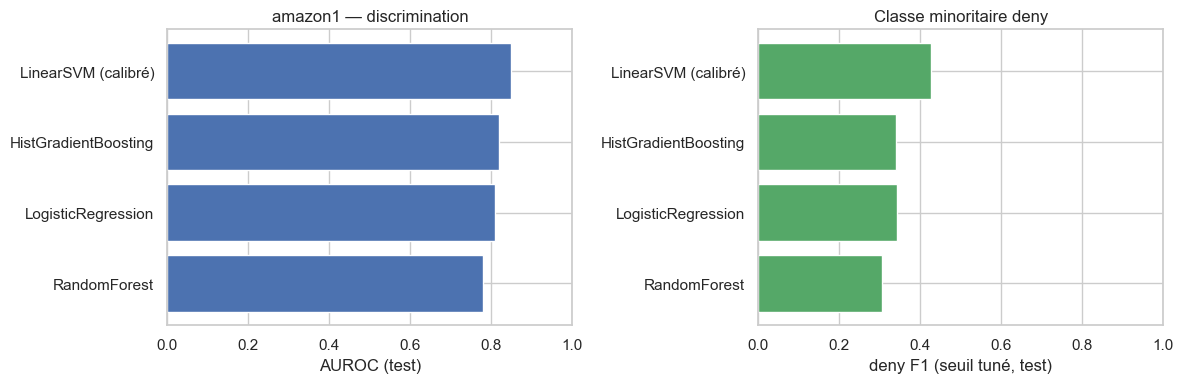

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
order = df.sort_values("test_auroc", ascending=True)["model"]
sub = df.set_index("model").loc[order]
ax.barh(sub.index, sub["test_auroc"], color="#4C72B0")
ax.set_xlabel("AUROC (test)")
ax.set_title(f"{DATASET_NAME} — discrimination")
ax.set_xlim(0, 1)

ax = axes[1]
ax.barh(sub.index, sub["test_deny_f1_tuned"], color="#55A868")
ax.set_xlabel("deny F1 (seuil tuné, test)")
ax.set_title("Classe minoritaire deny")
ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

## Matrice de confusion (meilleur modèle AUROC, seuil tuné)

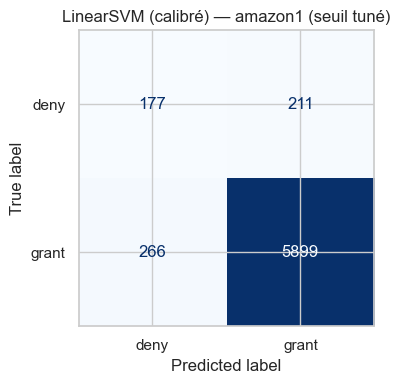

{'accuracy': 0.9272089119487258, 'confusion_matrix': [[177, 211], [266, 5899]], 'deny_precision': 0.39954853273137697, 'deny_recall': 0.45618556701030927, 'deny_f1': 0.4259927797833935, 'grant_recall': 0.956853203568532, 'balanced_accuracy': 0.7065193852894206, 'mean_proba_grant': 0.9432221862457635, 'mean_proba_grant_deny_only': 0.7962264012173039, 'mean_proba_grant_grant_only': 0.9524735024811314}


In [7]:
from sklearn.metrics import ConfusionMatrixDisplay

best_name = df.iloc[0]["model"]
best_row = next(r for r in results if r["model"] == best_name)
y_pred = best_row["y_pred_tuned"]

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=class_names,
    cmap="Blues",
    ax=ax,
    colorbar=False,
)
ax.set_title(f"{best_name} — {DATASET_NAME} (seuil tuné)")
plt.tight_layout()
plt.show()

print(summarize_binary_metrics(y_test, y_pred, best_row["estimator"].predict_proba(X_test)))

## (Optionnel) Comparer amazon1 / amazon2 / amazon3 — LogisticRegression rapide

Décommentez en mettant `COMPARE_ALL = True` (plus long : 3× préparation one-hot).

In [8]:
COMPARE_ALL = False

if COMPARE_ALL:
    cmp = []
    for name in ("amazon1", "amazon2", "amazon3"):
        p = prepare_dataset(specs[name], val_size=VAL_SIZE, random_state=RANDOM_STATE)
        clf = LogisticRegression(
            solver="saga", max_iter=300, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE
        )
        clf.fit(p.x_train, p.y_train)
        proba = clf.predict_proba(p.x_test)
        cmp.append({
            "dataset": name,
            "n_features": p.x_train.shape[1],
            "test_auroc": roc_auc_score(p.y_test, proba[:, 1]),
            "test_acc": accuracy_score(p.y_test, np.argmax(proba, axis=1)),
        })
    display(pd.DataFrame(cmp).round(4))
else:
    print("COMPARE_ALL=False")

COMPARE_ALL=False
